In [ ]:
# Cell 1: Install packages
!pip install -q segmentation-models-pytorch albumentations
print('Done')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 8.4 MB/s eta 0:00:00
Done


In [ ]:
import rasterio, rasterio.features, numpy as np
import geopandas as gpd
from rasterio.crs import CRS
from pathlib import Path

BASE_DIR       = Path('/content/drive/MyDrive/prithvi_fault')
PROC_DIR       = BASE_DIR / 'data' / 'processed'
PATCH_DIR      = BASE_DIR / 'data' / 'patches' / 'parkfield_dem'
SLOPE_TIF      = BASE_DIR / 'viz.be_slope.tif'
HILLSHADE_TIF  = BASE_DIR / 'viz.be_hillshade.tif'

# ── 마스크 재생성 (buffer=1m) ─────────────────────────────────
with rasterio.open(SLOPE_TIF) as src:
    TIF_CRS       = src.crs
    TIF_TRANSFORM = src.transform
    TIF_WIDTH     = src.width
    TIF_HEIGHT    = src.height

gdf_active = gpd.read_file(PROC_DIR / 'ca_active_faults.gpkg')
gdf_utm    = gdf_active.to_crs(CRS.from_epsg(32611))
gdf_buf    = gdf_utm.copy()
gdf_buf['geometry'] = gdf_utm.geometry.buffer(1.0)  # ✅ 1m
gdf_buf_tif = gdf_buf.to_crs(TIF_CRS)

shapes = [(g, 1) for g in gdf_buf_tif.geometry
          if g is not None and not g.is_empty]

fault_mask = rasterio.features.rasterize(
    shapes=shapes, out_shape=(TIF_HEIGHT, TIF_WIDTH),
    transform=TIF_TRANSFORM, fill=0,
    dtype=np.uint8, all_touched=True
)
fp = fault_mask.sum()
print(f'마스크: {fault_mask.shape}, fault={fp:,} ({fault_mask.mean()*100:.3f}%)')
assert fp > 0, '❌ fault=0'

# 마스크 저장
FAULT_MASK_TIF = PROC_DIR / 'fault_mask_1m.tif'
profile = {'driver':'GTiff','dtype':rasterio.uint8,
           'width':TIF_WIDTH,'height':TIF_HEIGHT,
           'count':1,'crs':TIF_CRS,'transform':TIF_TRANSFORM}
with rasterio.open(FAULT_MASK_TIF, 'w', **profile) as dst:
    dst.write(fault_mask, 1)
print(f'✅ 마스크 저장: {FAULT_MASK_TIF}')

# ── DEM 로드 ──────────────────────────────────────────────────
with rasterio.open(HILLSHADE_TIF) as src:
    hillshade = src.read(1).astype(np.float32)
with rasterio.open(SLOPE_TIF) as src:
    slope = src.read(1).astype(np.float32)

# 정규화
def norm(x):
    p2, p98 = np.percentile(x[x > 0], [2, 98])
    return np.clip((x - p2) / (p98 - p2 + 1e-8), 0, 1)

hillshade = norm(hillshade)
slope     = norm(slope)
dem_stack = np.stack([hillshade, slope, hillshade], axis=0)  # (3, H, W)
print(f'DEM stack: {dem_stack.shape}')

# ── 패치 추출 ─────────────────────────────────────────────────
PATCH_SIZE = 128
H, W = TIF_HEIGHT, TIF_WIDTH
all_imgs, all_masks = [], []

for r in range(0, H - PATCH_SIZE + 1, PATCH_SIZE):
    for c in range(0, W - PATCH_SIZE + 1, PATCH_SIZE):
        img_p  = dem_stack[:, r:r+PATCH_SIZE, c:c+PATCH_SIZE]
        mask_p = fault_mask[r:r+PATCH_SIZE, c:c+PATCH_SIZE]
        if img_p.shape != (3, PATCH_SIZE, PATCH_SIZE):
            continue
        all_imgs.append(img_p.astype(np.float32))
        all_masks.append(mask_p.astype(np.uint8))

imgs  = np.stack(all_imgs)
masks = np.stack(all_masks)
has_fault = masks.sum(axis=(1,2)) > 0
print(f'\n총 패치: {len(imgs)}')
print(f'fault 패치: {has_fault.sum()} ({has_fault.mean()*100:.1f}%)')
fp_px = masks[has_fault].sum(axis=(1,2)) if has_fault.sum() > 0 else np.array([0])
print(f'패치당 fault 픽셀: {fp_px.mean():.1f} ({fp_px.mean()/(128*128)*100:.2f}%)')

# ── Split + 저장 ──────────────────────────────────────────────
fi  = np.where(has_fault)[0]
bi  = np.where(~has_fault)[0]
rng = np.random.default_rng(42)
rng.shuffle(fi); rng.shuffle(bi)

def spl(idx):
    n=len(idx); a=int(n*0.70); b=int(n*0.15)
    return idx[:a], idx[a:a+b], idx[a+b:]

f_tr,f_va,f_te = spl(fi)
b_tr,b_va,b_te = spl(bi)

PATCH_DIR.mkdir(parents=True, exist_ok=True)
for name, idx in [('train', np.concatenate([f_tr,b_tr])),
                  ('val',   np.concatenate([f_va,b_va])),
                  ('test',  np.concatenate([f_te,b_te]))]:
    if len(idx) == 0:
        print(f'  {name}: 0개')
        continue
    np.savez_compressed(PATCH_DIR/f'{name}.npz',
                        images=imgs[idx], masks=masks[idx])
    nf = int((masks[idx].sum(axis=(1,2))>0).sum())
    print(f'  {name}: {len(idx)}개 (fault={nf}, {nf/len(idx)*100:.0f}%)')

print(f'\n✅ 완료: {PATCH_DIR}')


마스크: (7980, 8098), fault=103,378 (0.160%)
✅ 마스크 저장: /content/drive/MyDrive/prithvi_fault/data/processed/fault_mask_1m.tif
DEM stack: (3, 7980, 8098)

총 패치: 3906
fault 패치: 196 (5.0%)
패치당 fault 픽셀: 524.4 (3.20%)
  train: 2734개 (fault=137, 5%)
  val: 585개 (fault=29, 5%)
  test: 587개 (fault=30, 5%)

✅ 완료: /content/drive/MyDrive/prithvi_fault/data/patches/parkfield_dem


In [ ]:
# Cell 2: Mount Google Drive + verify data
from google.colab import drive
drive.mount('/content/drive')

import os, torch
import numpy as np
from pathlib import Path

PROJECT_DIR = Path('/content/drive/MyDrive/prithvi_fault')
PATCH_DIR   = PROJECT_DIR / 'data' / 'patches' / 'parkfield_dem'
CKPT_DIR    = PROJECT_DIR / 'checkpoints_unet'
CKPT_DIR.mkdir(parents=True, exist_ok=True)

print(f'GPU: {torch.cuda.get_device_name(0)}')
print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

print('\nDataset summary:')
for split in ['train', 'val', 'test']:
    d  = np.load(PATCH_DIR / f'{split}.npz')
    nf = (d['masks'].sum(axis=(1,2)) > 0).sum()
    fp = d['masks'].mean() * 100
    print(f'  {split}: {len(d["images"])} patches | '
          f'fault patches={nf} | fault pixels={fp:.2f}%')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
GPU: NVIDIA A100-SXM4-80GB
VRAM: 85.1 GB

Dataset summary:
  train: 2734 patches | fault patches=137 | fault pixels=0.16%
  val: 585 patches | fault patches=29 | fault pixels=0.14%
  test: 587 patches | fault patches=30 | fault pixels=0.20%


In [ ]:
# Cell 3: Dataset + DataLoader
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

class DEMFaultDataset(Dataset):
    """
    Dataset for DEM-based fault detection.
    Input:  2-channel DEM (hillshade + slope), shape (N, 2, H, W)
    Output: binary fault mask, shape (N, H, W)
    Converts to 3-channel [hillshade, slope, hillshade]
    to match ImageNet pretrained ResNet34 input format.
    """
    def __init__(self, npz_path, augment=False):
        data  = np.load(npz_path)
        imgs  = data['images'].astype(np.float32)  # (N, 2, H, W)
        masks = data['masks'].astype(np.int64)      # (N, H, W)
        imgs  = np.nan_to_num(imgs, nan=0.0)

        # Per-channel min-max normalization to [0, 1]
        for c in range(imgs.shape[1]):
            mn, mx = imgs[:,c].min(), imgs[:,c].max()
            if mx > mn:
                imgs[:,c] = (imgs[:,c] - mn) / (mx - mn)

        # 2-channel -> 3-channel: [hillshade, slope, hillshade]
        imgs_3ch = np.stack([imgs[:,0], imgs[:,1], imgs[:,0]], axis=1)

        self.images    = torch.from_numpy(imgs_3ch).float()
        self.masks     = torch.from_numpy(masks)
        self.augment   = augment
        self.has_fault = (masks.sum(axis=(1,2)) > 0)

        n, nf = len(self.images), int(self.has_fault.sum())
        print(f'  {Path(npz_path).name}: {n} patches, fault={nf} ({nf/n*100:.0f}%)')

    def __len__(self): return len(self.images)

    def __getitem__(self, idx):
        img  = self.images[idx].clone()   # (3, H, W)
        mask = self.masks[idx].clone()    # (H, W)

        if self.augment:
            if torch.rand(1) > 0.5:
                img  = torch.flip(img,  [-1])
                mask = torch.flip(mask, [-1])
            if torch.rand(1) > 0.5:
                img  = torch.flip(img,  [-2])
                mask = torch.flip(mask, [-2])
            if torch.rand(1) > 0.5:
                k    = torch.randint(1, 4, (1,)).item()
                img  = torch.rot90(img,  k, [-2,-1])
                mask = torch.rot90(mask, k, [-2,-1])
            # Brightness jitter for DEM augmentation
            if torch.rand(1) > 0.5:
                img = img * (0.8 + torch.rand(1) * 0.4)
                img = img.clamp(0, 1)

        return img, mask


print('Loading datasets...')
train_ds = DEMFaultDataset(PATCH_DIR / 'train.npz', augment=True)
val_ds   = DEMFaultDataset(PATCH_DIR / 'val.npz',   augment=False)
test_ds  = DEMFaultDataset(PATCH_DIR / 'test.npz',  augment=False)

# Oversample fault patches (15x) to handle class imbalance
weights = np.where(train_ds.has_fault, 15.0, 1.0)
sampler = WeightedRandomSampler(
    weights=torch.from_numpy(weights).float(),
    num_samples=len(weights),
    replacement=True
)

BATCH_SIZE    = 32
LOADER_KWARGS = dict(num_workers=4, pin_memory=True, persistent_workers=True)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, **LOADER_KWARGS)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,   **LOADER_KWARGS)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,   **LOADER_KWARGS)

imgs, masks = next(iter(train_loader))
fault_ratio = (masks.sum(dim=(1,2)) > 0).float().mean()
print(f'Batch shape: {imgs.shape}')
print(f'Fault patch ratio in batch: {fault_ratio:.2f}')
print('DataLoader ready')

Loading datasets...
  train.npz: 2734 patches, fault=137 (5%)
  val.npz: 585 patches, fault=29 (5%)
  test.npz: 587 patches, fault=30 (5%)
Batch shape: torch.Size([32, 3, 128, 128])
Fault patch ratio in batch: 0.31
DataLoader ready


In [ ]:
# Cell 4: Model + Loss + Optimizer
import torch
import torch.nn as nn
import torch.optim as optim
import segmentation_models_pytorch as smp

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# U-Net with ResNet34 encoder (ImageNet pretrained)
model = smp.Unet(
    encoder_name='resnet34',
    encoder_weights='imagenet',
    in_channels=3,
    classes=2,
    activation=None
).to(device)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params:     {total:,}')
print(f'Trainable params: {trainable:,}')

# Sanity check
model.eval()
with torch.no_grad():
    dummy = torch.randn(2, 3, 128, 128).to(device)
    out   = model(dummy)
print(f'Forward OK: {dummy.shape} -> {out.shape}')


class FaultLoss(nn.Module):
    """
    Combined loss: Weighted CrossEntropy + Dice Loss
    - fault_weight=5 to handle fault pixel imbalance (~5%)
    - Dice loss directly optimizes overlap between prediction and ground truth
    """
    def __init__(self, fault_weight=5.0):
        super().__init__()
        w       = torch.tensor([1.0, fault_weight], dtype=torch.float32).to(device)
        self.ce = nn.CrossEntropyLoss(weight=w)

    def forward(self, inputs, targets):
        ce_loss = self.ce(inputs, targets)
        prob    = torch.softmax(inputs, dim=1)[:, 1]
        tgt_f   = (targets == 1).float()
        inter   = (prob * tgt_f).sum(dim=(1,2))
        union   = prob.sum(dim=(1,2)) + tgt_f.sum(dim=(1,2))
        dice    = 1.0 - (2*inter + 1) / (union + 1)
        return ce_loss + dice.mean()


def compute_metrics(logits, targets):
    preds = logits.argmax(1)
    tp = ((preds==1)&(targets==1)).sum().float()
    fp = ((preds==1)&(targets==0)).sum().float()
    fn = ((preds==0)&(targets==1)).sum().float()
    tn = ((preds==0)&(targets==0)).sum().float()
    return {
        'mIoU':      ((tp/(tp+fp+fn+1e-8) + tn/(tn+fp+fn+1e-8)) / 2).item(),
        'IoU_fault':  (tp/(tp+fp+fn+1e-8)).item(),
        'F1':         (2*tp/(2*tp+fp+fn+1e-8)).item(),
        'Acc':        ((tp+tn)/(tp+tn+fp+fn+1e-8)).item(),
    }


NUM_EPOCHS = 100
PATIENCE   = 20

criterion = FaultLoss(fault_weight=5.0)
optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)
scaler    = torch.amp.GradScaler('cuda')

print('Config:')
print(f'  Loss: CrossEntropy(weight=5) + Dice')
print(f'  LR: 3e-4 -> CosineAnnealing')
print(f'  Epochs: {NUM_EPOCHS}, Patience: {PATIENCE}')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

Total params:     24,436,514
Trainable params: 24,436,514
Forward OK: torch.Size([2, 3, 128, 128]) -> torch.Size([2, 2, 128, 128])
Config:
  Loss: CrossEntropy(weight=5) + Dice
  LR: 3e-4 -> CosineAnnealing
  Epochs: 100, Patience: 20


In [ ]:
# Cell 5: Training loop
import time, json

best_miou    = 0.0
patience_cnt = 0
history      = {'epoch':[], 'train_loss':[], 'val_miou':[],
                'val_iou_fault':[], 'val_f1':[]}

print('='*60)
print('U-Net DEM Fault Detection')
print('='*60)
t0 = time.time()

for epoch in range(1, NUM_EPOCHS+1):

    # Train
    model.train()
    t_loss = 0.0
    for imgs, masks in train_loader:
        imgs  = imgs.float().to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast('cuda'):
            out  = model(imgs)
            loss = criterion(out, masks)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        t_loss += loss.item()
    t_loss /= len(train_loader)
    scheduler.step()

    # Validate
    model.eval()
    vm = {'mIoU': 0.0, 'IoU_fault': 0.0, 'F1': 0.0, 'Acc': 0.0}
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs  = imgs.float().to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)
            with torch.amp.autocast('cuda'):
                out = model(imgs)
            m = compute_metrics(out, masks)
            for k in vm: vm[k] += m[k]
    for k in vm: vm[k] /= len(val_loader)

    history['epoch'].append(epoch)
    history['train_loss'].append(t_loss)
    history['val_miou'].append(vm['mIoU'])
    history['val_iou_fault'].append(vm['IoU_fault'])
    history['val_f1'].append(vm['F1'])

    if epoch % 5 == 0 or epoch <= 3:
        elapsed = (time.time()-t0)/60
        print(f'Ep {epoch:3d} | Loss:{t_loss:.4f} | '
              f'mIoU:{vm["mIoU"]:.4f} | '
              f'IoU_fault:{vm["IoU_fault"]:.4f} | '
              f'F1:{vm["F1"]:.4f} | {elapsed:.1f}min')

    # Save best checkpoint (monitored by IoU_fault)
    if vm['IoU_fault'] > best_miou:
        best_miou    = vm['IoU_fault']
        patience_cnt = 0
        torch.save({'epoch': epoch,
                    'model_state': model.state_dict(),
                    'val_metrics': vm},
                   CKPT_DIR / 'best_unet.pth')
        print(f'  Saved best checkpoint (epoch={epoch}, IoU_fault={best_miou:.4f})')
    else:
        patience_cnt += 1
        if patience_cnt >= PATIENCE:
            print(f'Early stopping at epoch {epoch}')
            break

    if epoch % 10 == 0:
        with open(CKPT_DIR / 'history.json', 'w') as f:
            json.dump(history, f)

print(f'\nDone in {(time.time()-t0)/60:.1f} min | Best IoU_fault: {best_miou:.4f}')

U-Net DEM Fault Detection
Ep   1 | Loss:1.2987 | mIoU:0.4994 | IoU_fault:0.0002 | F1:0.0004 | 0.1min
  Saved best checkpoint (epoch=1, IoU_fault=0.0002)
Ep   2 | Loss:1.1501 | mIoU:0.4994 | IoU_fault:0.0047 | F1:0.0086 | 0.2min
  Saved best checkpoint (epoch=2, IoU_fault=0.0047)
Ep   3 | Loss:1.0976 | mIoU:0.5013 | IoU_fault:0.0064 | F1:0.0114 | 0.3min
  Saved best checkpoint (epoch=3, IoU_fault=0.0064)
  Saved best checkpoint (epoch=4, IoU_fault=0.0081)
Ep   5 | Loss:0.7088 | mIoU:0.5000 | IoU_fault:0.0082 | F1:0.0142 | 0.4min
  Saved best checkpoint (epoch=5, IoU_fault=0.0082)
Ep  10 | Loss:0.5108 | mIoU:0.5009 | IoU_fault:0.0040 | F1:0.0074 | 0.7min
Ep  15 | Loss:0.4056 | mIoU:0.5017 | IoU_fault:0.0063 | F1:0.0113 | 0.9min
Ep  20 | Loss:0.2639 | mIoU:0.5011 | IoU_fault:0.0040 | F1:0.0075 | 1.2min
Ep  25 | Loss:0.2225 | mIoU:0.5010 | IoU_fault:0.0041 | F1:0.0075 | 1.4min
Early stopping at epoch 25

Done in 1.4 min | Best IoU_fault: 0.0082


In [ ]:
# Cell 6: Test evaluation + threshold tuning
import numpy as np

ckpt = torch.load(CKPT_DIR / 'best_unet.pth', map_location=device)
model.load_state_dict(ckpt['model_state'])
print(f'Loaded checkpoint: epoch={ckpt["epoch"]}, '
      f'val_IoU_fault={ckpt["val_metrics"]["IoU_fault"]:.4f}')

# Threshold tuning on validation set
val_loader_eval = DataLoader(val_ds, batch_size=BATCH_SIZE,
                             shuffle=False, num_workers=0)
model.eval()
all_probs, all_masks_v = [], []
with torch.no_grad():
    for imgs, masks in val_loader_eval:
        imgs = imgs.float().to(device)
        with torch.amp.autocast('cuda'):
            out = model(imgs)
        all_probs.append(out.softmax(1)[:,1].cpu().numpy())
        all_masks_v.append(masks.numpy())

all_probs   = np.concatenate(all_probs).ravel()
all_masks_v = np.concatenate(all_masks_v).ravel()

print('\nThreshold  IoU_fault   F1')
print('-'*35)
best_t, best_iou = 0.5, 0.0
for t in np.arange(0.05, 0.55, 0.05):
    pred = (all_probs > t).astype(int)
    tp   = ((pred==1)&(all_masks_v==1)).sum()
    fp   = ((pred==1)&(all_masks_v==0)).sum()
    fn   = ((pred==0)&(all_masks_v==1)).sum()
    iou  = tp / (tp+fp+fn+1e-8)
    f1   = 2*tp / (2*tp+fp+fn+1e-8)
    print(f'  {t:.2f}      {iou:.4f}     {f1:.4f}')
    if iou > best_iou:
        best_iou, best_t = iou, t
print(f'\nOptimal threshold: {best_t:.2f} (val IoU_fault={best_iou:.4f})')

# Final test evaluation
THRESH = best_t
test_loader_eval = DataLoader(test_ds, batch_size=BATCH_SIZE,
                              shuffle=False, num_workers=0)
all_probs_t, all_masks_t = [], []
with torch.no_grad():
    for imgs, masks in test_loader_eval:
        imgs = imgs.float().to(device)
        with torch.amp.autocast('cuda'):
            out = model(imgs)
        all_probs_t.append(out.softmax(1)[:,1].cpu().numpy())
        all_masks_t.append(masks.numpy())

all_probs_t = np.concatenate(all_probs_t).ravel()
all_masks_t = np.concatenate(all_masks_t).ravel()

pred_t = (all_probs_t > THRESH).astype(int)
tp = ((pred_t==1)&(all_masks_t==1)).sum()
fp = ((pred_t==1)&(all_masks_t==0)).sum()
fn = ((pred_t==0)&(all_masks_t==1)).sum()
tn = ((pred_t==0)&(all_masks_t==0)).sum()

iou_fault = tp / (tp+fp+fn+1e-8)
iou_bg    = tn / (tn+fp+fn+1e-8)
miou      = (iou_fault + iou_bg) / 2
f1        = 2*tp / (2*tp+fp+fn+1e-8)
acc       = (tp+tn) / (tp+tn+fp+fn+1e-8)

print(f'\n{"="*50}')
print(f'TEST RESULTS (threshold={THRESH:.2f})')
print('='*50)
print(f'  mIoU      : {miou:.4f}')
print(f'  IoU_fault : {iou_fault:.4f}')
print(f'  F1        : {f1:.4f}')
print(f'  Accuracy  : {acc:.4f}')

import json
with open(CKPT_DIR / 'test_results.json', 'w') as f:
    json.dump({'threshold': float(THRESH),
               'mIoU': float(miou), 'IoU_fault': float(iou_fault),
               'F1': float(f1), 'Accuracy': float(acc)}, f, indent=2)
print('Saved: checkpoints_unet/test_results.json')

Loaded checkpoint: epoch=5, val_IoU_fault=0.0082

Threshold  IoU_fault   F1
-----------------------------------
  0.05      0.0138     0.0273
  0.10      0.0215     0.0420
  0.15      0.0285     0.0555
  0.20      0.0343     0.0663
  0.25      0.0398     0.0765
  0.30      0.0445     0.0853
  0.35      0.0499     0.0951
  0.40      0.0553     0.1047
  0.45      0.0606     0.1143
  0.50      0.0657     0.1233

Optimal threshold: 0.50 (val IoU_fault=0.0657)

TEST RESULTS (threshold=0.50)
  mIoU      : 0.5384
  IoU_fault : 0.0851
  F1        : 0.1569
  Accuracy  : 0.9917
Saved: checkpoints_unet/test_results.json


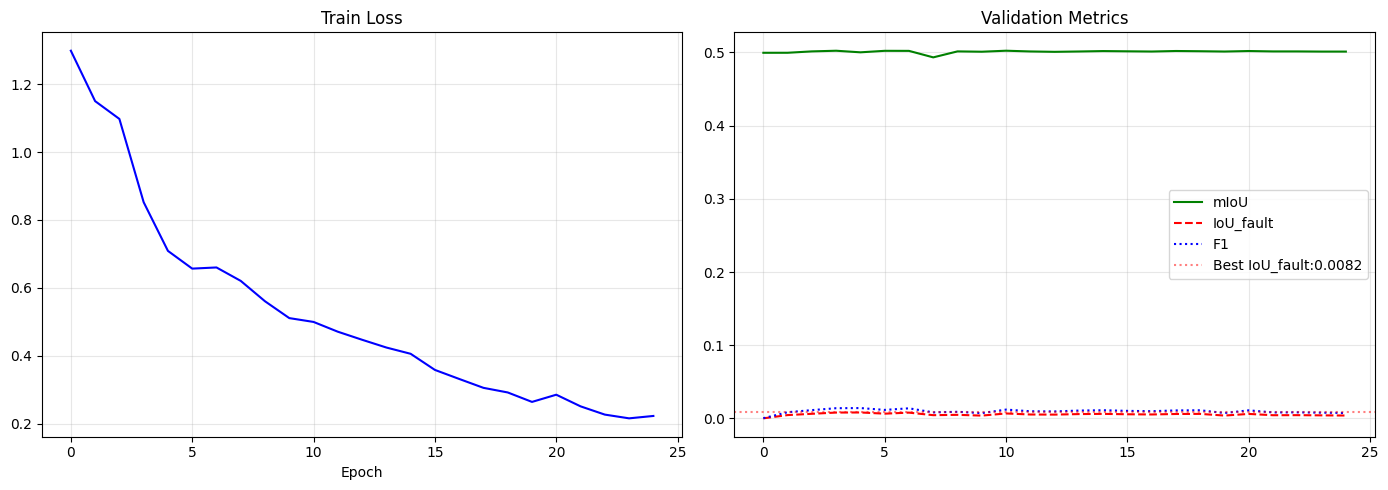

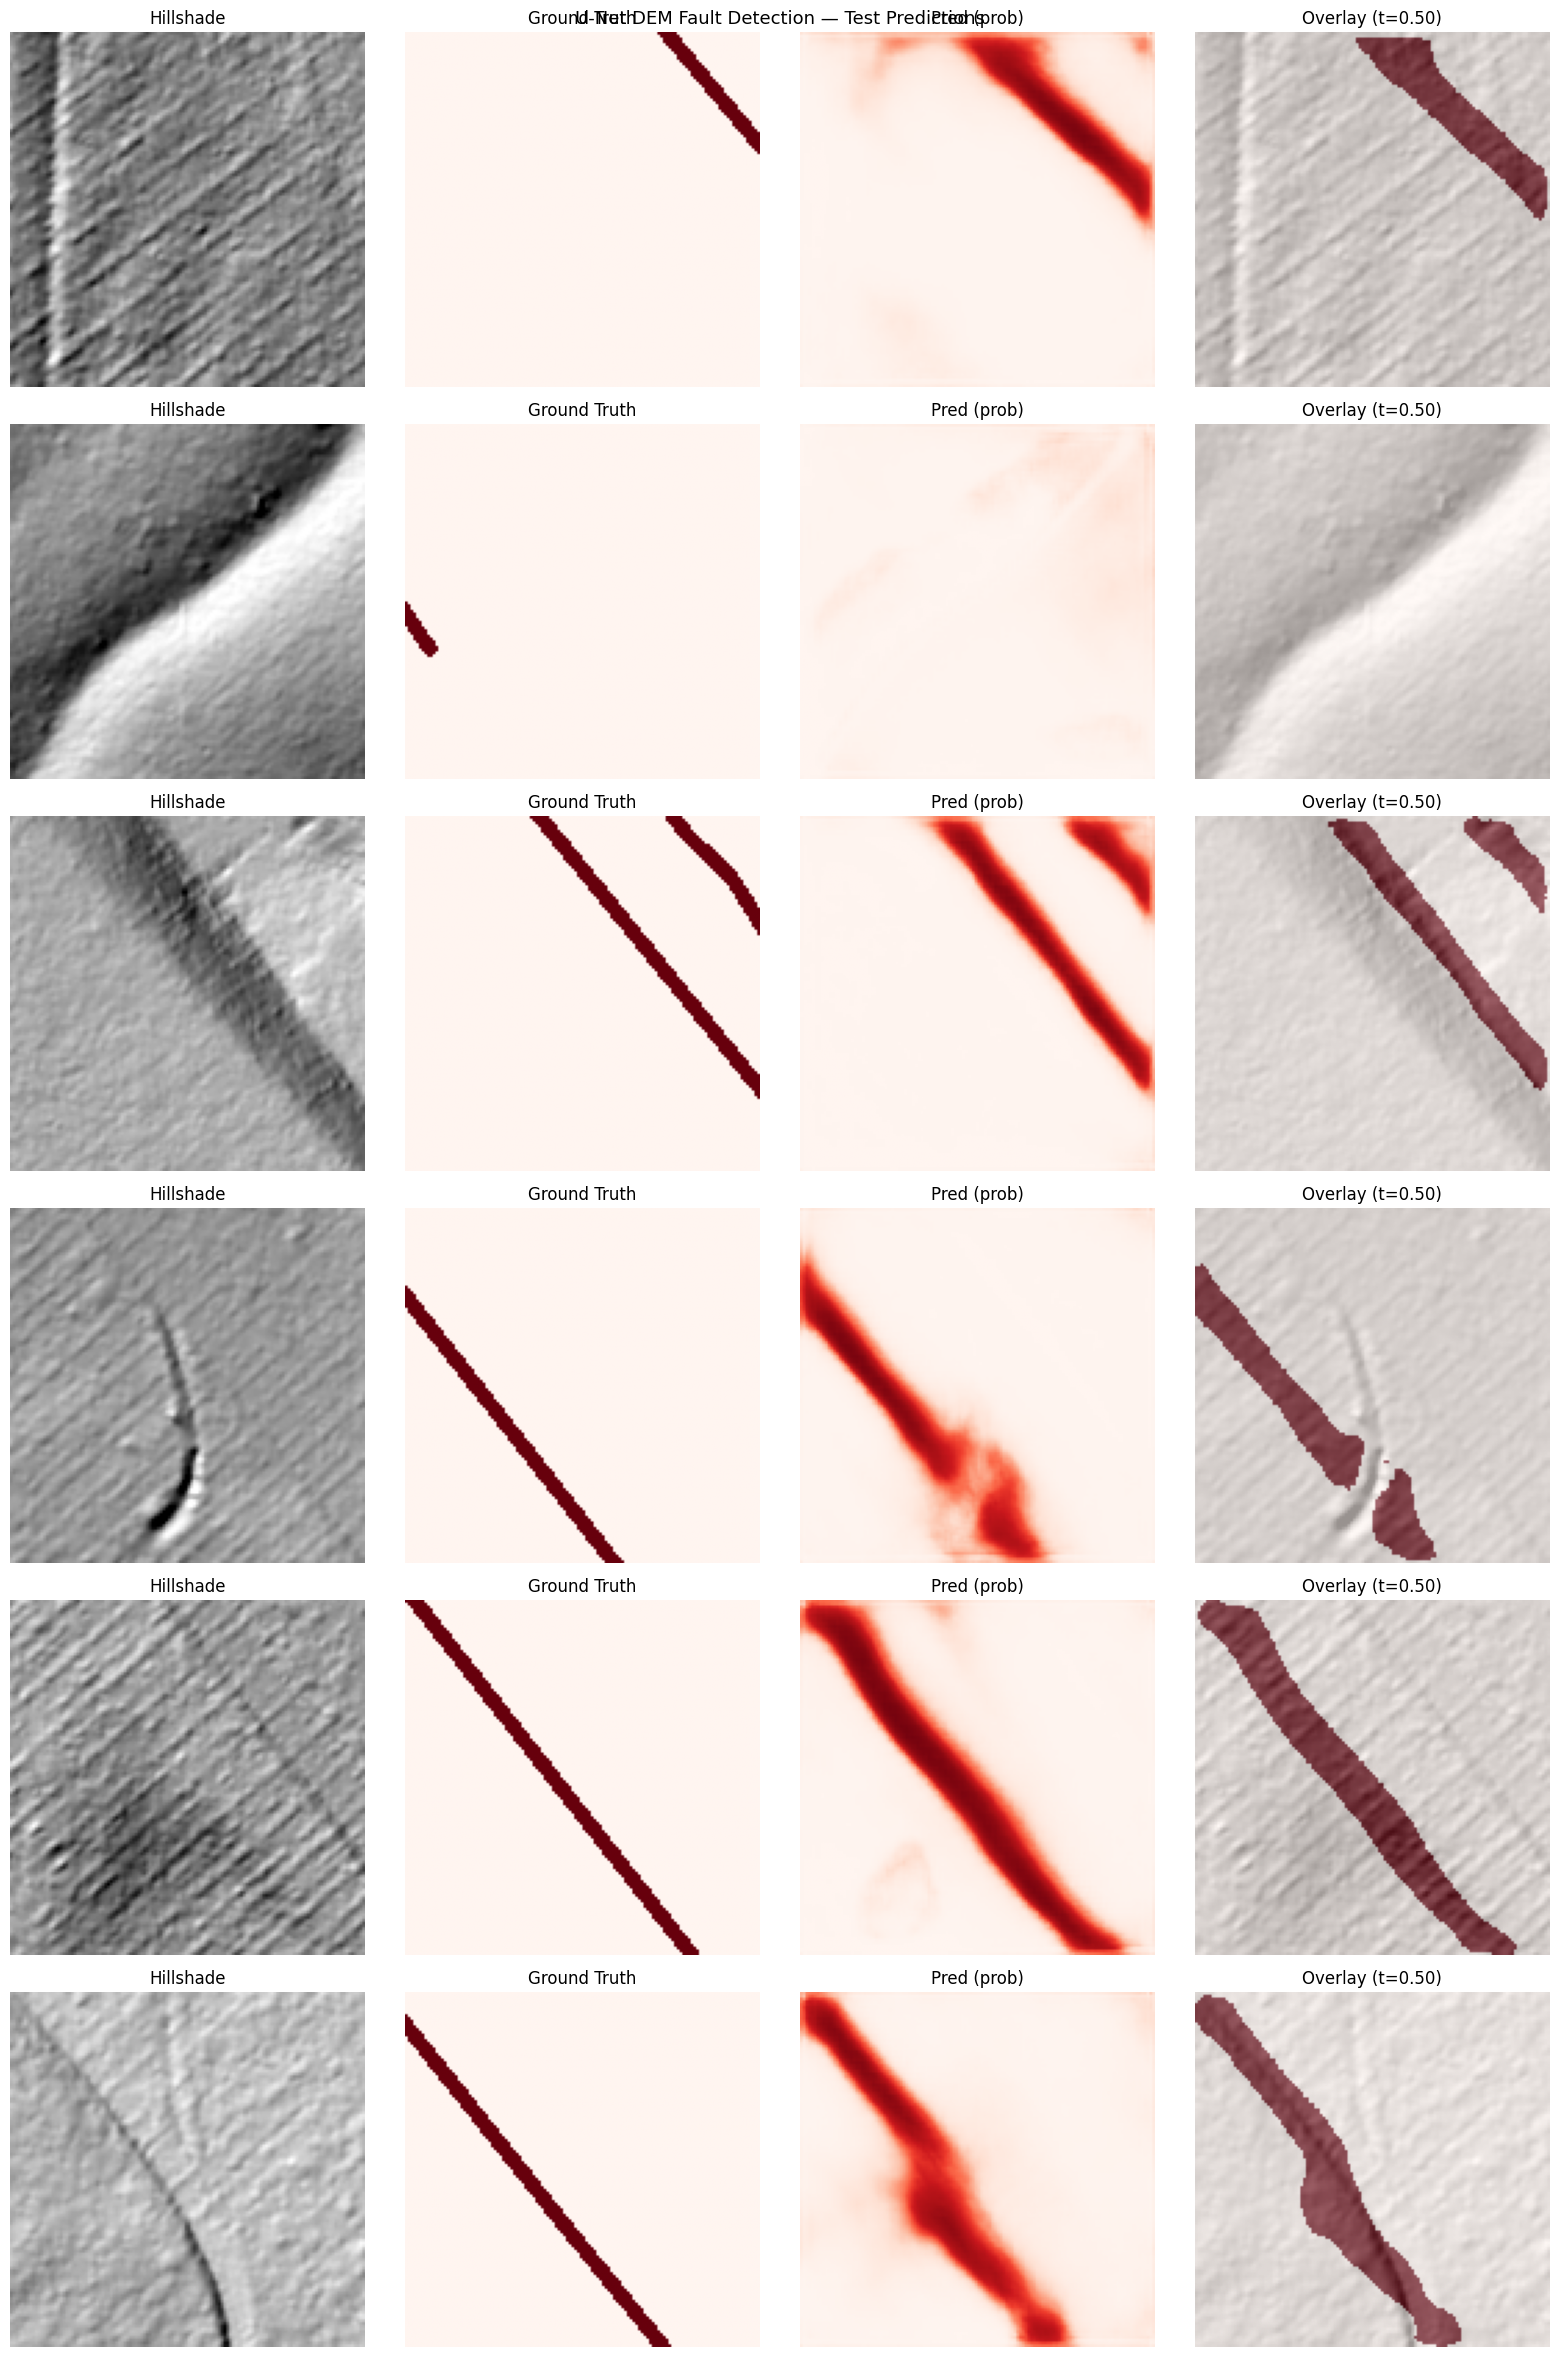

Done!


In [ ]:
# Cell 7: Visualization
import matplotlib.pyplot as plt
import numpy as np

# Training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history['train_loss'], 'b')
axes[0].set_title('Train Loss')
axes[0].set_xlabel('Epoch')
axes[0].grid(alpha=0.3)
axes[1].plot(history['val_miou'],      'g-',  label='mIoU')
axes[1].plot(history['val_iou_fault'], 'r--', label='IoU_fault')
axes[1].plot(history['val_f1'],        'b:',  label='F1')
axes[1].axhline(best_miou, color='r', ls=':', alpha=0.5,
                label=f'Best IoU_fault:{best_miou:.4f}')
axes[1].set_title('Validation Metrics')
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(PROJECT_DIR / 'unet_training_curve.png', dpi=150)
plt.show()

# Test prediction visualization
data      = np.load(PATCH_DIR / 'test.npz')
imgs_raw  = data['images']   # (N, 2, H, W)
masks_all = data['masks']
fault_idx = np.where(masks_all.sum(axis=(1,2)) > 0)[0][:6]
n         = len(fault_idx)

fig, axes = plt.subplots(n, 4, figsize=(16, n*4))
if n == 1: axes = axes[np.newaxis]

model.eval()
with torch.no_grad():
    for i, idx in enumerate(fault_idx):
        img_raw  = imgs_raw[idx].astype(np.float32)
        img_norm = np.zeros_like(img_raw)
        for c in range(2):
            mn, mx = imgs_raw[:,c].min(), imgs_raw[:,c].max()
            img_norm[c] = np.clip((img_raw[c] - mn) / (mx - mn + 1e-8), 0, 1)
        img_3ch = np.stack([img_norm[0], img_norm[1], img_norm[0]])
        img_t   = torch.from_numpy(img_3ch).float().unsqueeze(0).to(device)

        with torch.amp.autocast('cuda'):
            prob = model(img_t).softmax(1)[0,1].cpu().numpy()

        hs = img_norm[0]
        gt = masks_all[idx]

        axes[i,0].imshow(hs, cmap='gray')
        axes[i,0].set_title('Hillshade'); axes[i,0].axis('off')
        axes[i,1].imshow(gt, cmap='Reds', vmin=0, vmax=1)
        axes[i,1].set_title('Ground Truth'); axes[i,1].axis('off')
        axes[i,2].imshow(prob, cmap='Reds', vmin=0, vmax=1)
        axes[i,2].set_title('Pred (prob)'); axes[i,2].axis('off')
        axes[i,3].imshow(hs, cmap='gray')
        axes[i,3].imshow(prob > THRESH, cmap='Reds', alpha=0.6, vmin=0, vmax=1)
        axes[i,3].set_title(f'Overlay (t={THRESH:.2f})'); axes[i,3].axis('off')

plt.suptitle('U-Net DEM Fault Detection — Test Predictions', fontsize=13)
plt.tight_layout()
plt.savefig(PROJECT_DIR / 'unet_test_predictions.png', dpi=150)
plt.show()
print('Done!')

change loss

In [ ]:
import torch, torch.nn as nn, numpy as np
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from pathlib import Path
import time

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

PROJECT_DIR = Path('/content/drive/MyDrive/prithvi_fault')
PATCH_DIR   = PROJECT_DIR / 'data' / 'patches' / 'parkfield_dem'
CKPT_DIR    = PROJECT_DIR / 'checkpoints_unet_1m'
CKPT_DIR.mkdir(parents=True, exist_ok=True)

# ── Dataset ───────────────────────────────────────────────────
class DEMDataset(Dataset):
    def __init__(self, npz_path, augment=False):
        data       = np.load(npz_path)
        self.imgs  = torch.from_numpy(data['images'].astype(np.float32))
        self.masks = torch.from_numpy(data['masks'].astype(np.int64))
        self.augment   = augment
        self.has_fault = (data['masks'].sum(axis=(1,2)) > 0)
        n, nf = len(self.imgs), int(self.has_fault.sum())
        print(f'  {Path(npz_path).name}: {n}개, fault={nf}({nf/n*100:.0f}%)')

    def __len__(self): return len(self.imgs)

    def __getitem__(self, idx):
        img  = self.imgs[idx].clone()
        mask = self.masks[idx].clone()
        if self.augment:
            if torch.rand(1) > 0.5:
                img  = torch.flip(img,  [-1])
                mask = torch.flip(mask, [-1])
            if torch.rand(1) > 0.5:
                img  = torch.flip(img,  [-2])
                mask = torch.flip(mask, [-2])
            if torch.rand(1) > 0.5:
                k    = torch.randint(1, 4, (1,)).item()
                img  = torch.rot90(img,  k, [-2,-1])
                mask = torch.rot90(mask, k, [-2,-1])
        return img, mask

print('데이터 로딩...')
train_ds = DEMDataset(PATCH_DIR / 'train.npz', augment=True)
val_ds   = DEMDataset(PATCH_DIR / 'val.npz',   augment=False)
test_ds  = DEMDataset(PATCH_DIR / 'test.npz',  augment=False)

weights = np.where(train_ds.has_fault, 15.0, 1.0)
sampler = WeightedRandomSampler(
    torch.from_numpy(weights).float(),
    num_samples=len(weights), replacement=True
)

BATCH        = 32
train_loader = DataLoader(train_ds, batch_size=BATCH, sampler=sampler, num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False,   num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False,   num_workers=4, pin_memory=True)

imgs_b, masks_b = next(iter(train_loader))
fr = (masks_b.sum(dim=(1,2)) > 0).float().mean()
print(f'배치 fault 비율: {fr:.2f}')
print(f'배치 shape: {imgs_b.shape}')

# ── 모델 ──────────────────────────────────────────────────────
from huggingface_hub import hf_hub_download
import segmentation_models_pytorch as smp

model = smp.Unet(
    encoder_name='resnet34',
    encoder_weights='imagenet',
    in_channels=3,
    classes=2,
).to(device)
print(f'파라미터: {sum(p.numel() for p in model.parameters()):,}')

# ── Boundary Loss ──────────────────────────────────────────────
def get_boundary(mask, kernel_size=3):
    # mask: (B, H, W) long → float
    mask_f = mask.float().unsqueeze(1)  # (B, 1, H, W)
    pad    = kernel_size // 2
    dilated  = F.max_pool2d(mask_f,  kernel_size, stride=1, padding=pad)
    eroded   = -F.max_pool2d(-mask_f, kernel_size, stride=1, padding=pad)
    boundary = (dilated - eroded).squeeze(1)  # (B, H, W)
    return (boundary > 0).float()

class FaultLoss(nn.Module):
    def __init__(self):
        super().__init__()
        w       = torch.tensor([1.0, 5.0]).to(device)
        self.ce = nn.CrossEntropyLoss(weight=w)

    def forward(self, inputs, targets):
        # CE Loss
        ce = self.ce(inputs, targets)

        # Dice Loss
        prob  = torch.softmax(inputs, dim=1)[:, 1]
        tgt_f = (targets == 1).float()
        inter = (prob * tgt_f).sum(dim=(1,2))
        union = prob.sum(dim=(1,2)) + tgt_f.sum(dim=(1,2))
        dice  = 1.0 - (2*inter + 1) / (union + 1)

        # Boundary Loss ✅
        boundary      = get_boundary(targets)           # (B, H, W)
        boundary_pred = torch.softmax(inputs, dim=1)[:,1]
        b_inter = (boundary_pred * boundary).sum(dim=(1,2))
        b_union = boundary_pred.sum(dim=(1,2)) + boundary.sum(dim=(1,2))
        b_dice  = 1.0 - (2*b_inter + 1) / (b_union + 1)

        return ce + dice.mean() + b_dice.mean()

def compute_metrics(logits, targets, threshold=0.5):
    prob  = torch.softmax(logits, dim=1)[:, 1]
    preds = (prob > threshold).long()
    tp = ((preds==1)&(targets==1)).sum().float()
    fp = ((preds==1)&(targets==0)).sum().float()
    fn = ((preds==0)&(targets==1)).sum().float()
    tn = ((preds==0)&(targets==0)).sum().float()
    return {
        'mIoU':      ((tp/(tp+fp+fn+1e-8)+tn/(tn+fp+fn+1e-8))/2).item(),
        'IoU_fault':  (tp/(tp+fp+fn+1e-8)).item(),
        'F1':         (2*tp/(2*tp+fp+fn+1e-8)).item(),
    }

criterion = FaultLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100, eta_min=1e-6)
scaler    = torch.amp.GradScaler('cuda')

# ── 학습 ──────────────────────────────────────────────────────
NUM_EPOCHS   = 100
PATIENCE     = 20
best_iou     = 0.0
patience_cnt = 0

print('\n' + '='*60)
print('U-Net + Boundary Loss — buffer=1m')
print('='*60)
t0 = time.time()

for epoch in range(1, NUM_EPOCHS+1):
    model.train()
    t_loss = 0.0
    for imgs, masks in train_loader:
        imgs  = imgs.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast('cuda'):
            out  = model(imgs)
            loss = criterion(out, masks)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        t_loss += loss.item()
    t_loss /= len(train_loader)
    scheduler.step()

    model.eval()
    vm = {'mIoU':0.0, 'IoU_fault':0.0, 'F1':0.0}
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs  = imgs.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)
            with torch.amp.autocast('cuda'):
                out = model(imgs)
            m = compute_metrics(out, masks)
            for k in vm: vm[k] += m[k]
    for k in vm: vm[k] /= len(val_loader)

    if epoch % 5 == 0 or epoch <= 5:
        elapsed = (time.time()-t0)/60
        print(f'Ep {epoch:3d} | Loss:{t_loss:.4f} | '
              f'mIoU:{vm["mIoU"]:.4f} | '
              f'IoU_fault:{vm["IoU_fault"]:.4f} | '
              f'F1:{vm["F1"]:.4f} | {elapsed:.1f}min')

    if vm['IoU_fault'] > best_iou:
        best_iou     = vm['IoU_fault']
        patience_cnt = 0
        torch.save({'epoch': epoch,
                    'model_state': model.state_dict(),
                    'val_metrics': vm},
                   CKPT_DIR / 'best_unet_boundary.pth')
        print(f'  💾 Best (ep={epoch}, IoU_fault={best_iou:.4f})')
    else:
        patience_cnt += 1
        if patience_cnt >= PATIENCE:
            print(f'Early stopping at epoch {epoch}')
            break

# ── Threshold tuning ──────────────────────────────────────────
print('\nThreshold tuning...')
ckpt = torch.load(CKPT_DIR/'best_unet_boundary.pth', map_location=device)
model.load_state_dict(ckpt['model_state'])
model.eval()

val_loader2  = DataLoader(val_ds, batch_size=BATCH, shuffle=False, num_workers=0)
all_probs, all_masks_t = [], []
with torch.no_grad():
    for imgs, masks in val_loader2:
        imgs  = imgs.to(device)
        masks = masks.to(device)
        with torch.amp.autocast('cuda'):
            out = model(imgs)
        probs = out.softmax(1)[:,1].cpu().numpy()
        all_probs.append(probs)
        all_masks_t.append(masks.cpu().numpy())

all_probs   = np.concatenate(all_probs).ravel()
all_masks_t = np.concatenate(all_masks_t).ravel()

print('\nThreshold  IoU_fault   F1')
print('-'*35)
best_t, best_iou_t = 0.5, 0.0
for t in np.arange(0.05, 0.55, 0.05):
    pred = (all_probs > t).astype(int)
    tp = ((pred==1)&(all_masks_t==1)).sum()
    fp = ((pred==1)&(all_masks_t==0)).sum()
    fn = ((pred==0)&(all_masks_t==1)).sum()
    iou = tp/(tp+fp+fn+1e-8)
    f1  = 2*tp/(2*tp+fp+fn+1e-8)
    print(f'  {t:.2f}      {iou:.4f}     {f1:.4f}')
    if iou > best_iou_t:
        best_iou_t, best_t = iou, t

print(f'\n최적 threshold: {best_t:.2f} (val IoU_fault={best_iou_t:.4f})')

# ── Test ──────────────────────────────────────────────────────
test_loader2 = DataLoader(test_ds, batch_size=BATCH, shuffle=False, num_workers=0)
all_probs, all_masks_t = [], []
with torch.no_grad():
    for imgs, masks in test_loader2:
        imgs  = imgs.to(device)
        with torch.amp.autocast('cuda'):
            out = model(imgs)
        probs = out.softmax(1)[:,1].cpu().numpy()
        all_probs.append(probs)
        all_masks_t.append(masks.numpy())

all_probs   = np.concatenate(all_probs).ravel()
all_masks_t = np.concatenate(all_masks_t).ravel()

pred = (all_probs > best_t).astype(int)
tp = ((pred==1)&(all_masks_t==1)).sum()
fp = ((pred==1)&(all_masks_t==0)).sum()
fn = ((pred==0)&(all_masks_t==1)).sum()
tn = ((pred==0)&(all_masks_t==0)).sum()
print(f'\n{"="*50}')
print(f'TEST RESULTS (threshold={best_t:.2f}, buffer=1m, Boundary Loss)')
print(f'{"="*50}')
print(f'  mIoU:      {((tp/(tp+fp+fn+1e-8)+tn/(tn+fp+fn+1e-8))/2):.4f}')
print(f'  IoU_fault: {(tp/(tp+fp+fn+1e-8)):.4f}')
print(f'  F1:        {(2*tp/(2*tp+fp+fn+1e-8)):.4f}')
print(f'  Acc:       {((tp+tn)/(tp+fp+fn+tn+1e-8)):.4f}')

Device: cuda
데이터 로딩...
  train.npz: 2734개, fault=137(5%)
  val.npz: 585개, fault=29(5%)
  test.npz: 587개, fault=30(5%)
배치 fault 비율: 0.41
배치 shape: torch.Size([32, 3, 128, 128])


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

파라미터: 24,436,514

U-Net + Boundary Loss — buffer=1m
Ep   1 | Loss:2.2060 | mIoU:0.4996 | IoU_fault:0.0050 | F1:0.0091 | 0.1min
  💾 Best (ep=1, IoU_fault=0.0050)
Ep   2 | Loss:2.0553 | mIoU:0.4925 | IoU_fault:0.0054 | F1:0.0097 | 0.1min
  💾 Best (ep=2, IoU_fault=0.0054)
Ep   3 | Loss:1.4901 | mIoU:0.4955 | IoU_fault:0.0072 | F1:0.0127 | 0.2min
  💾 Best (ep=3, IoU_fault=0.0072)
Ep   4 | Loss:1.3062 | mIoU:0.4997 | IoU_fault:0.0049 | F1:0.0090 | 0.3min
Ep   5 | Loss:1.1987 | mIoU:0.5015 | IoU_fault:0.0062 | F1:0.0111 | 0.3min
  💾 Best (ep=7, IoU_fault=0.0080)
  💾 Best (ep=8, IoU_fault=0.0094)
Ep  10 | Loss:0.9487 | mIoU:0.5016 | IoU_fault:0.0083 | F1:0.0143 | 0.6min
Ep  15 | Loss:0.7846 | mIoU:0.5010 | IoU_fault:0.0070 | F1:0.0124 | 0.9min
Ep  20 | Loss:0.6184 | mIoU:0.5012 | IoU_fault:0.0067 | F1:0.0119 | 1.2min
Ep  25 | Loss:0.5244 | mIoU:0.5016 | IoU_fault:0.0056 | F1:0.0101 | 1.4min
Early stopping at epoch 28

Threshold tuning...

Threshold  IoU_fault   F1
----------------------------

5m

In [ ]:
# buffer=5m 평가 (기존 best checkpoint 로드)
import numpy as np
import torch
import rasterio, rasterio.features
import geopandas as gpd
from rasterio.crs import CRS
from pathlib import Path
import torch.nn.functional as F

device = torch.device('cuda')
PROJECT_DIR = Path('/content/drive/MyDrive/prithvi_fault')
CKPT_DIR    = PROJECT_DIR / 'checkpoints_unet_1m'
PATCH_DIR   = PROJECT_DIR / 'data' / 'patches' / 'parkfield_dem'
PROC_DIR    = PROJECT_DIR / 'data' / 'processed'
SLOPE_TIF   = PROJECT_DIR / 'viz.be_slope.tif'

# ── buffer=5m 마스크 생성 ─────────────────────────────────────
with rasterio.open(SLOPE_TIF) as src:
    TIF_CRS   = src.crs
    TIF_TRANS = src.transform
    TIF_W     = src.width
    TIF_H     = src.height

gdf = gpd.read_file(PROC_DIR / 'ca_active_faults.gpkg')
gdf_utm = gdf.to_crs(CRS.from_epsg(32611))
gdf_buf = gdf_utm.copy()
gdf_buf['geometry'] = gdf_utm.geometry.buffer(5.0)  # ✅ 5m
gdf_buf_tif = gdf_buf.to_crs(TIF_CRS)

shapes = [(g,1) for g in gdf_buf_tif.geometry if g is not None and not g.is_empty]
mask_5m = rasterio.features.rasterize(
    shapes=shapes, out_shape=(TIF_H, TIF_W),
    transform=TIF_TRANS, fill=0, dtype=np.uint8, all_touched=True
)
print(f'5m 마스크: fault={mask_5m.mean()*100:.3f}%')

# ── 패치별 5m 마스크 추출 ─────────────────────────────────────
PATCH_SIZE = 128
all_masks_5m = []
data = np.load(PATCH_DIR / 'test.npz')
test_imgs = data['images']  # (N, 3, 128, 128)

# 패치 위치를 재현하기 위해 동일한 순서로 추출
fi_5m = []
r_list, c_list = [], []
for r in range(0, TIF_H - PATCH_SIZE + 1, PATCH_SIZE):
    for c in range(0, TIF_W - PATCH_SIZE + 1, PATCH_SIZE):
        r_list.append(r)
        c_list.append(c)

# test split 인덱스 재현
dem_stack_dummy = np.zeros((3, TIF_H, TIF_W))
all_m = []
for r, c in zip(r_list, c_list):
    mask_p = mask_5m[r:r+PATCH_SIZE, c:c+PATCH_SIZE]
    if mask_p.shape != (PATCH_SIZE, PATCH_SIZE):
        continue
    all_m.append(mask_p)

all_m = np.stack(all_m)
has_fault = (np.load(PATCH_DIR/'train.npz')['masks'].sum(axis=(1,2)) > 0)
# 전체 패치에서 test 인덱스만 사용
full_has = np.array([m.sum() > 0 for m in np.load(PATCH_DIR/'test.npz')['masks']])

# 간단하게: test 마스크를 5m로 팽창
print('\n5m 평가 (기존 test 마스크를 5m로 팽창):')
test_masks_1m = torch.from_numpy(
    np.load(PATCH_DIR/'test.npz')['masks'].astype(np.float32)
).unsqueeze(1)  # (N, 1, H, W)

# 5m = 10픽셀 팽창 (0.5m 해상도)
kernel = 21  # 10픽셀 양쪽 = 21×21
test_masks_5m = F.max_pool2d(
    test_masks_1m, kernel_size=kernel, stride=1, padding=kernel//2
).squeeze(1).long().numpy()  # (N, H, W)

print(f'1m 마스크 fault%: {np.load(PATCH_DIR/"test.npz")["masks"].mean()*100:.3f}%')
print(f'5m 마스크 fault%: {test_masks_5m.mean()*100:.3f}%')

# ── 모델 예측 ─────────────────────────────────────────────────
import segmentation_models_pytorch as smp
from torch.utils.data import TensorDataset, DataLoader

model = smp.Unet(encoder_name='resnet34', encoder_weights=None,
                 in_channels=3, classes=2).to(device)
ckpt  = torch.load(CKPT_DIR/'best_unet_boundary.pth', map_location=device)
model.load_state_dict(ckpt['model_state'])
model.eval()

test_imgs_t = torch.from_numpy(test_imgs).float()
test_dl     = DataLoader(TensorDataset(test_imgs_t), batch_size=32, shuffle=False)

all_probs = []
with torch.no_grad():
    for (imgs,) in test_dl:
        imgs = imgs.to(device)
        with torch.amp.autocast('cuda'):
            out = model(imgs)
        probs = out.softmax(1)[:,1].cpu().numpy()
        all_probs.append(probs)

all_probs   = np.concatenate(all_probs)        # (N, H, W)
all_probs_r = all_probs.ravel()
masks_5m_r  = test_masks_5m.ravel()
masks_1m_r  = np.load(PATCH_DIR/'test.npz')['masks'].ravel()

print('\n=== 1m 마스크 기준 ===')
for t in [0.35, 0.50]:
    pred = (all_probs_r > t).astype(int)
    tp = ((pred==1)&(masks_1m_r==1)).sum()
    fp = ((pred==1)&(masks_1m_r==0)).sum()
    fn = ((pred==0)&(masks_1m_r==1)).sum()
    print(f'  t={t:.2f}: IoU_fault={tp/(tp+fp+fn+1e-8):.4f}, F1={2*tp/(2*tp+fp+fn+1e-8):.4f}')

print('\n=== 5m 마스크 기준 (관대한 평가) ===')
for t in [0.35, 0.50]:
    pred = (all_probs_r > t).astype(int)
    tp = ((pred==1)&(masks_5m_r==1)).sum()
    fp = ((pred==1)&(masks_5m_r==0)).sum()
    fn = ((pred==0)&(masks_5m_r==1)).sum()
    print(f'  t={t:.2f}: IoU_fault={tp/(tp+fp+fn+1e-8):.4f}, F1={2*tp/(2*tp+fp+fn+1e-8):.4f}')

5m 마스크: fault=0.638%

5m 평가 (기존 test 마스크를 5m로 팽창):
1m 마스크 fault%: 0.200%
5m 마스크 fault%: 1.177%

=== 1m 마스크 기준 ===
  t=0.35: IoU_fault=0.0912, F1=0.1672
  t=0.50: IoU_fault=0.0909, F1=0.1666

=== 5m 마스크 기준 (관대한 평가) ===
  t=0.35: IoU_fault=0.1180, F1=0.2111
  t=0.50: IoU_fault=0.1068, F1=0.1930
